In [1]:
import os
import pandas as pd

import pandas as pd
import os

# Load the dataset.csv file
df = pd.read_csv(r'C:\Users\rqpua\Downloads\dataset.csv')
df.head()

,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11,Symptom_12,Symptom_13,Symptom_14,Symptom_15,Symptom_16,Symptom_17
0,Fungal infection,itching,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Fungal infection,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Fungal infection,itching,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Fungal infection,itching,skin_rash,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Fungal infection,itching,skin_rash,nodal_skin_eruptions,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
## Data Cleaning step

df.fillna(0,inplace=True)

In [3]:
# Clean the data 
df_clean = df.copy()
symptom_cols = [col for col in df.columns if col.startswith('Symptom_')]

#Clean the symptom strings 
for col in symptom_cols:
    df_clean[col] = df_clean[col].apply(lambda x: x.strip() if isinstance(x, str) else x)

#Apply standardization for names of similiar meaning
symptom_mapping = {
    'abdominal_pain': 'stomach_pain',
    'belly_pain': 'stomach_pain'
}

for col in symptom_cols:
    df_clean[col] = df_clean[col].replace(symptom_mapping)

#Get unique symptoms and clean them
all_symptoms_clean = df_clean[symptom_cols].values.flatten()
unique_symptoms_clean = pd.unique(all_symptoms_clean)

# Filter out NaN, 0, and empty values, then convert to strings
unique_symptoms_clean = [str(s).strip() for s in unique_symptoms_clean 
                        if not pd.isna(s) and s != 0 and s != '0' and str(s).strip() != '']

# Remove duplicates after cleaning
unique_symptoms_clean = list(set(unique_symptoms_clean))

print(f"After proper standardization: {len(unique_symptoms_clean)} unique symptoms")
print("Standardized symptoms:")
for symptom in sorted(unique_symptoms_clean):
    print(f"- {symptom}")

After proper standardization: 129 unique symptoms
Standardized symptoms:
- abnormal_menstruation
- acidity
- acute_liver_failure
- altered_sensorium
- anxiety
- back_pain
- blackheads
- bladder_discomfort
- blister
- blood_in_sputum
- bloody_stool
- blurred_and_distorted_vision
- breathlessness
- brittle_nails
- bruising
- burning_micturition
- chest_pain
- chills
- cold_hands_and_feets
- coma
- congestion
- constipation
- continuous_feel_of_urine
- continuous_sneezing
- cough
- cramps
- dark_urine
- dehydration
- depression
- diarrhoea
- dischromic _patches
- distention_of_abdomen
- dizziness
- drying_and_tingling_lips
- enlarged_thyroid
- excessive_hunger
- extra_marital_contacts
- family_history
- fast_heart_rate
- fatigue
- fluid_overload
- foul_smell_of urine
- headache
- high_fever
- hip_joint_pain
- history_of_alcohol_consumption
- increased_appetite
- indigestion
- inflammatory_nails
- internal_itching
- irregular_sugar_level
- irritability
- irritation_in_anus
- itching
- join

In [4]:
df_clean.head()

,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11,Symptom_12,Symptom_13,Symptom_14,Symptom_15,Symptom_16,Symptom_17
0,Fungal infection,itching,skin_rash,nodal_skin_eruptions,dischromic _patches,0,0,0,0,0,0,0,0,0,0,0,0,0
1,Fungal infection,skin_rash,nodal_skin_eruptions,dischromic _patches,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,Fungal infection,itching,nodal_skin_eruptions,dischromic _patches,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,Fungal infection,itching,skin_rash,dischromic _patches,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,Fungal infection,itching,skin_rash,nodal_skin_eruptions,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [6]:
# Get all unique non-zero symptoms
all_symptoms = []
for col in df.columns[1:]:
    all_symptoms.extend(df[col].unique())

all_symptoms = sorted([s for s in set(all_symptoms) if s != 0])

# Create the binary dataframe
binary_data = []
for idx, row in df.iterrows():
    disease = row['Disease']
    present_symptoms = set(row[1:]) - {0}  # Remove zeros

    row_dict = {'Disease': disease}
    for symptom in all_symptoms:
        row_dict[symptom] = 1 if symptom in present_symptoms else 0

    binary_data.append(row_dict)

binary_df = pd.DataFrame(binary_data)
binary_df.head()

,Disease,abdominal_pain,abnormal_menstruation,acidity,acute_liver_failure,altered_sensorium,anxiety,back_pain,belly_pain,blackheads,...,watering_from_eyes,weakness_in_limbs,weakness_of_one_body_side,weight_gain,weight_loss,yellow_crust_ooze,yellow_urine,yellowing_of_eyes,yellowish_skin,itching
0,Fungal infection,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,Fungal infection,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,Fungal infection,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,Fungal infection,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,Fungal infection,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [8]:
 binary_df['Disease'].nunique()

41

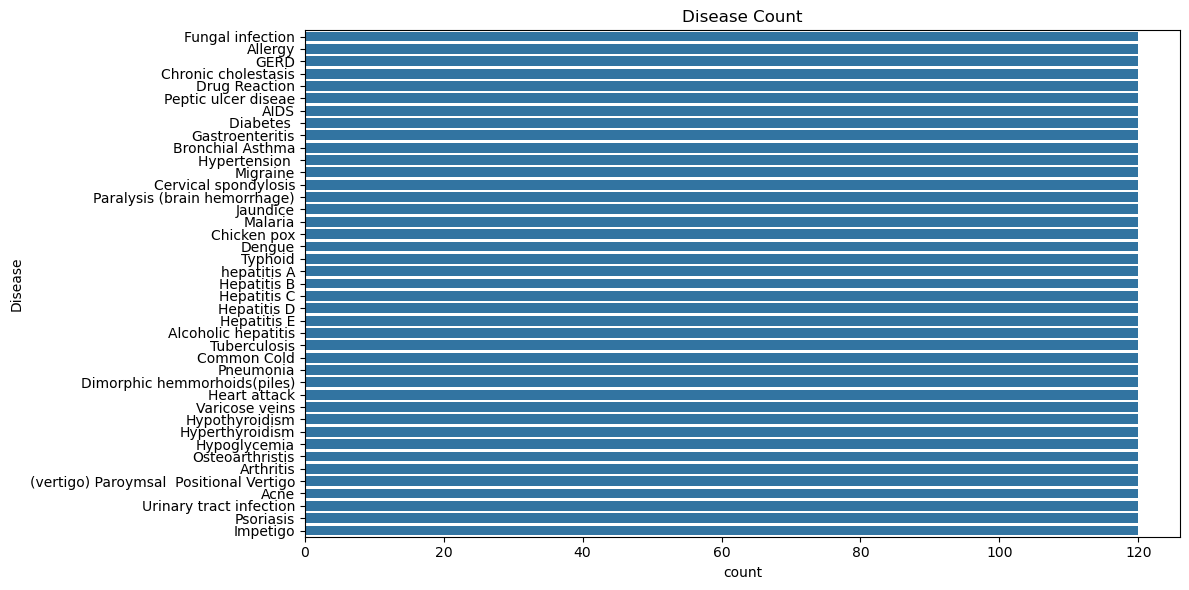

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
# Plot number of cases per disease
plt.figure(figsize=(12,6))
sns.countplot(y='Disease', data=df, order=binary_df['Disease'].value_counts().index)
plt.title("Disease Count")
plt.tight_layout()
plt.show()

In [10]:
# Separate features and labels
X = binary_df.drop('Disease', axis=1)
y = binary_df['Disease']



In [11]:
# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# RandomForest gives excellent performance for this type of data
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [13]:
def predict_disease_from_symptoms():
    print("=== Disease Prediction from Symptoms ===")
    print("Available symptoms:")
    print("-" * 40)

    symptoms = X.columns.tolist()

    # Display all symptoms with numbers
    for i, symptom in enumerate(symptoms, 1):
        print(f"{i}. {symptom}")

    print("\n" + "=" * 40)
    print("Enter the numbers of symptoms you have (one per line)")
    print("Enter '0' when you're done")
    print("=" * 40)

    user_input = [0] * len(symptoms)  # Start with all symptoms as 0
    selected_symptoms = []

    while True:
        try:
            choice = input("\nEnter symptom number (or 0 to finish): ").strip()

            if choice == '0':
                break

            choice_num = int(choice)

            if 1 <= choice_num <= len(symptoms):
                symptom_index = choice_num - 1
                symptom_name = symptoms[symptom_index]

                if user_input[symptom_index] == 0:
                    user_input[symptom_index] = 1
                    selected_symptoms.append(symptom_name)
                    print(f"Added: {symptom_name}")
                    print(f"Current symptoms: {', '.join(selected_symptoms) if selected_symptoms else 'None'}")
                else:
                    print(f"{symptom_name} is already selected")
            else:
                print(f"Please enter a number between 1 and {len(symptoms)}")

        except ValueError:
            print("Please enter a valid number")

    # Convert to DataFrame with proper column names
    user_data = pd.DataFrame([user_input], columns=symptoms)

    # Make prediction
    prediction = model.predict(user_data)[0]
    probability = model.predict_proba(user_data)[0]
    confidence = max(probability)

    print(f"\n" + "=" * 50)
    print("=== PREDICTION RESULT ===")
    print(f"Selected symptoms: {', '.join(selected_symptoms) if selected_symptoms else 'None'}")
    print(f"Predicted Disease: {prediction}")
    print(f"Confidence: {confidence:.2%}")
    print("=" * 50)

    # Show top 3 predictions
    if hasattr(model, 'classes_'):
        prob_dict = dict(zip(model.classes_, probability))
        sorted_probs = sorted(prob_dict.items(), key=lambda x: x[1], reverse=True)[:3]

        print("\nTop 3 possible diseases:")
        for i, (disease, prob) in enumerate(sorted_probs, 1):
            print(f"{i}. {disease}: {prob:.2%}")

    return prediction, probability

# Run the predictor
result = predict_disease_from_symptoms()

=== Disease Prediction from Symptoms ===
Available symptoms:
----------------------------------------
1.  abdominal_pain
2.  abnormal_menstruation
3.  acidity
4.  acute_liver_failure
5.  altered_sensorium
6.  anxiety
7.  back_pain
8.  belly_pain
9.  blackheads
10.  bladder_discomfort
11.  blister
12.  blood_in_sputum
13.  bloody_stool
14.  blurred_and_distorted_vision
15.  breathlessness
16.  brittle_nails
17.  bruising
18.  burning_micturition
19.  chest_pain
20.  chills
21.  cold_hands_and_feets
22.  coma
23.  congestion
24.  constipation
25.  continuous_feel_of_urine
26.  continuous_sneezing
27.  cough
28.  cramps
29.  dark_urine
30.  dehydration
31.  depression
32.  diarrhoea
33.  dischromic _patches
34.  distention_of_abdomen
35.  dizziness
36.  drying_and_tingling_lips
37.  enlarged_thyroid
38.  excessive_hunger
39.  extra_marital_contacts
40.  family_history
41.  fast_heart_rate
42.  fatigue
43.  fluid_overload
44.  foul_smell_of urine
45.  headache
46.  high_fever
47.  hip_join


Enter symptom number (or 0 to finish):  33


Added:  dischromic _patches
Current symptoms:  dischromic _patches



Enter symptom number (or 0 to finish):  100


Added:  skin_rash
Current symptoms:  dischromic _patches,  skin_rash



Enter symptom number (or 0 to finish):  0



=== PREDICTION RESULT ===
Selected symptoms:  dischromic _patches,  skin_rash
Predicted Disease: Fungal infection
Confidence: 68.00%

Top 3 possible diseases:
1. Fungal infection: 68.00%
2. Acne: 9.00%
3. Psoriasis: 8.00%
